## **House Sales Price Prediction Training**

There are many factors that are considered when determining the price of a house. This [House Sales Price test_data](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview) records 79 attributes of various houses as well as their price, and stores them in the "train.csv" file.

This data is part of a competition, where the goal is to train models with the "train.csv", and then make predictions on the "test.csv", and submit your predictions for an evaluation, where submissions are evaluated on Root-Mean-Squared-Error (RMSE). 

The goal of this competition is to practice Regression Techniques, so we will be focused on training a linear regression model as well as a random forest model and use ensemble learning to combine the predictions of both models. 

The following sections are outlined as follows:
- Cleaning the Data
- Linear Regression Training

### **Cleaning the Data**

In [719]:
# Importing Modules

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import warnings
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

In [720]:
data = pd.read_csv("train.csv")

In [721]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [722]:
# General stats from our set
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


Since we are planning on performing Linear Regression, let's find the distribution of our target:

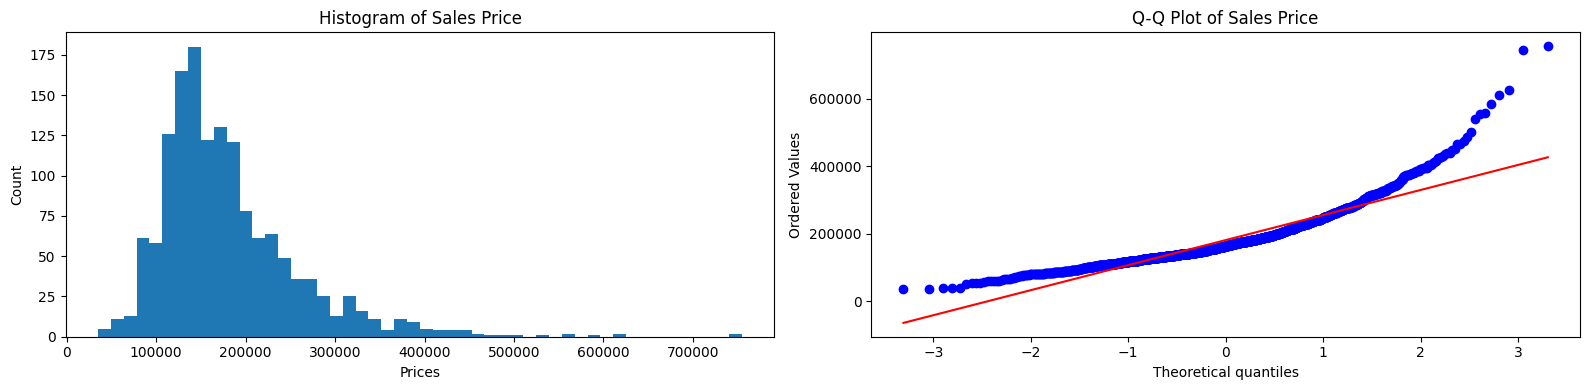

In [723]:
# Plot a histogram and qq-plot of the SalesPrice column:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(data["SalePrice"], bins=50)
axes[0].set_xlabel("Prices")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram of Sales Price")

stats.probplot(data["SalePrice"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Sales Price")

plt.tight_layout()
plt.show()

We can tell from the histogram and qq-plot that our data is right-skewed. If we want to make an inference using linear regression, we need to assume our residuals are normally distributed. In order to meet this assumption, let's transform the data, log is a common choice:

In [724]:
# Transform the data.
data["SalePrice"] = np.log(data["SalePrice"])

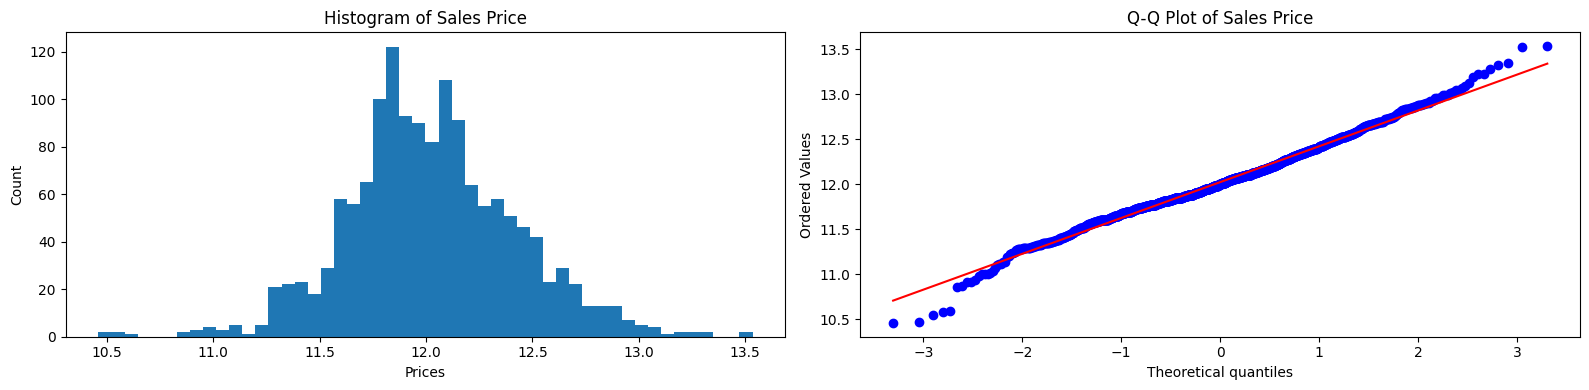

In [725]:
# Plot a histogram and qq-plot of the transformed SalesPrice column:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(data["SalePrice"], bins=50)
axes[0].set_xlabel("Prices")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram of Sales Price")

stats.probplot(data["SalePrice"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Sales Price")

plt.tight_layout()
plt.show()

We can see the data is now normally distributed, meaning the assumption is met. 

The next thing we should handle is the NAN entries in our training data. In majority of these columns, having an NAN entry does not mean that the data wasn't recorded, it means that house doesn't have that particular feature. This holds for all the columns with categorical features, so we can just replace NAN entries with "None".

For numeric columns, there are some instances where a NAN entry does mean the data was not recorded, so for those instances, we can replace NAN entries with the median of that column.

For the other entries we can just replace NAN entries with 0.

In [726]:
# Numeric columns that can replace NAN entries with 0.
zero_fill_cols = ["GarageYrBlt", "MasVnrArea", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "BsmtFinSF1", "2ndFlrSF", "LowQualFinSF", "BsmtFullBath", "BsmtHalfBath", "Fireplaces", "GarageCars", 
                  "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal"]

# Numeric columns that should replace NAN entries with the median.
median_fill_cols = ["LotFrontage", "LotArea", "OverallQual", "OverallCond", "YearRemodAdd", "YearBuilt", "GrLivArea", "FullBath", "HalfBath", "1stFlrSF", "BedroomAbvGr", 
                    "KitchenAbvGr", "TotRmsAbvGrd"]

# Replace NAN entries for numeric columns.
data[zero_fill_cols] = data[zero_fill_cols].fillna(0)

data[median_fill_cols] = data[median_fill_cols].fillna(data[median_fill_cols].median())

# For the other categorical columns, fill with "None".
data = data.fillna("None")

Speaking of categorical features, one important thing we need to is create indicator features for each categorical column that we have, we'll first see which columns are categorical in our data, but before that, let's record all numeric columns to use for normalization later:

In [727]:
#data.drop("Street", axis=1, inplace=True)
#data.drop("Utilities", axis=1, inplace=True)

data = data.drop(columns=["Street", "Utilities", "PoolQC", "MiscFeature", "GarageYrBlt"])

In [728]:
# For normalization later:
num_cols = data.select_dtypes(include=["int64", "float64"]).columns.to_list()
num_cols = [col for col in num_cols if col not in ["Id", "SalePrice"]]

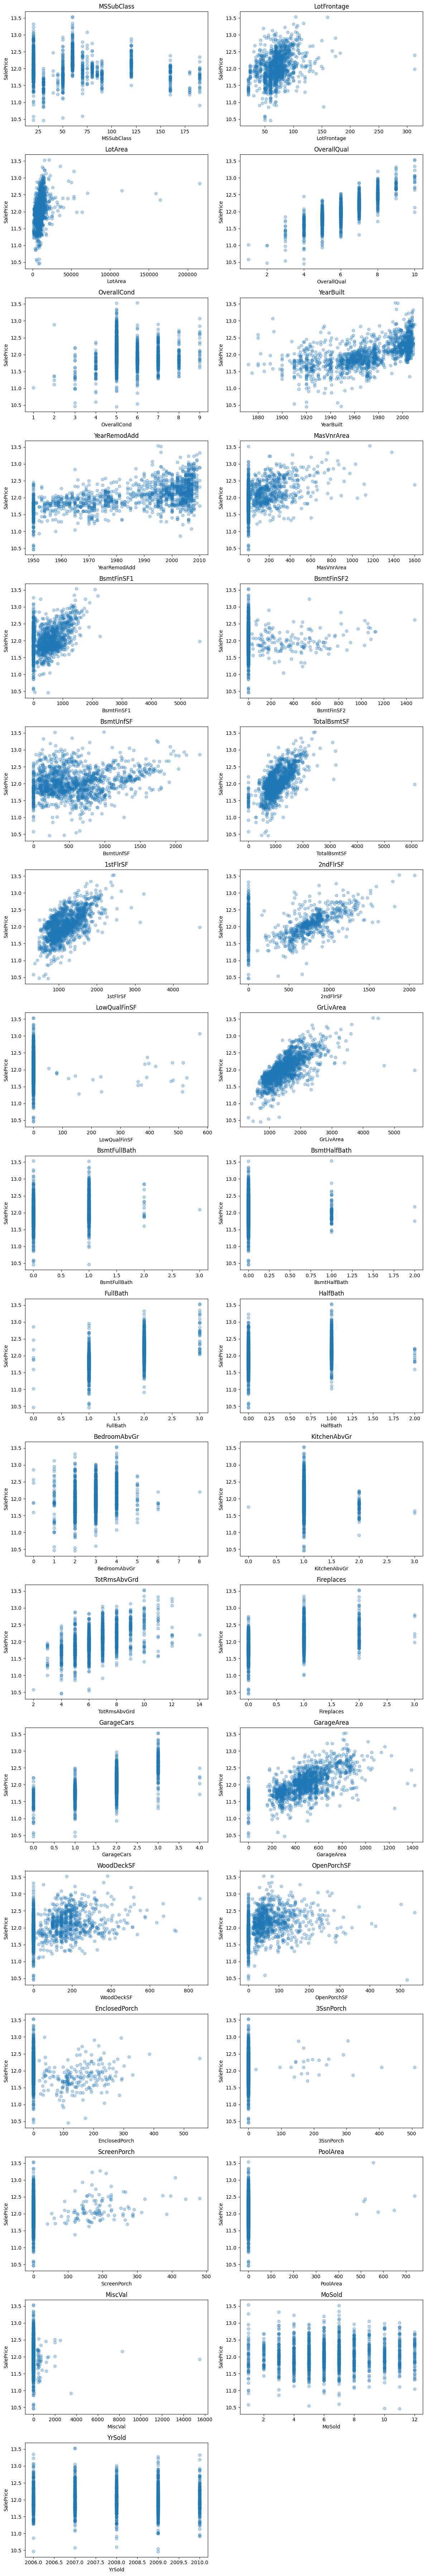

In [729]:
fig, axes = plt.subplots(
    nrows=(len(num_cols) + 1) // 2,
    ncols=2,
    figsize=(12, 4 * ((len(num_cols) + 1) // 2))
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(data[col], data["SalePrice"], alpha=0.3)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("SalePrice")
    axes[i].set_title(col)

# Remove empty subplot if odd number of plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [730]:
# One-hot encode ONLY this.
numeric_categorize_cols = ["MSSubClass"]

log_cols = [col for col in num_cols
            if col not in numeric_categorize_cols]

norm_cols = log_cols.copy()

In [731]:
data[log_cols] = np.log1p(data[log_cols])

In [732]:
obj_cols = data.select_dtypes(include="object").columns.to_numpy()
print(obj_cols)

['MSZoning' 'Alley' 'LotShape' 'LandContour' 'LotConfig' 'LandSlope'
 'Neighborhood' 'Condition1' 'Condition2' 'BldgType' 'HouseStyle'
 'RoofStyle' 'RoofMatl' 'Exterior1st' 'Exterior2nd' 'MasVnrType'
 'ExterQual' 'ExterCond' 'Foundation' 'BsmtQual' 'BsmtCond' 'BsmtExposure'
 'BsmtFinType1' 'BsmtFinType2' 'Heating' 'HeatingQC' 'CentralAir'
 'Electrical' 'KitchenQual' 'Functional' 'FireplaceQu' 'GarageType'
 'GarageFinish' 'GarageQual' 'GarageCond' 'PavedDrive' 'Fence' 'SaleType'
 'SaleCondition']


Next we need to create an indicator feature for each category in a categorical column, so let's create a function that does that:

In [733]:
# Function to create categorical variables for columns with multiple categories.
def create_categorical_variables(data: pd.DataFrame, col: str, categories: list[str]) -> None:

    print(f"\n Creating Categorical Variables for column {col}:")

    # Create a categorical variable for each category.
    for category in categories:
        new_col = col + "-" + category
        data[new_col] = data[col].apply(lambda x: 1 if category == str(x) else 0)
        
        print(f" Created: {new_col}")

    # Drop the original column.
    data.drop(col, axis=1, inplace=True)

Now let's go through each categorical column and create their indicator features, we should make sure to add a "None" feature for each category to handle the NAN entries:

In [734]:
for col in obj_cols:
    categories = list(data[col].unique())

    if "None" not in categories:
        categories.append("None")

    create_categorical_variables(data, col, categories)

for col2 in numeric_categorize_cols:
    categories = data[col2].unique().astype(str).tolist()

    if "None" not in categories:
        categories.append("None")
        
    create_categorical_variables(data, col2, categories)


 Creating Categorical Variables for column MSZoning:
 Created: MSZoning-RL
 Created: MSZoning-RM
 Created: MSZoning-C (all)
 Created: MSZoning-FV
 Created: MSZoning-RH
 Created: MSZoning-None

 Creating Categorical Variables for column Alley:
 Created: Alley-None
 Created: Alley-Grvl
 Created: Alley-Pave

 Creating Categorical Variables for column LotShape:
 Created: LotShape-Reg
 Created: LotShape-IR1
 Created: LotShape-IR2
 Created: LotShape-IR3
 Created: LotShape-None

 Creating Categorical Variables for column LandContour:
 Created: LandContour-Lvl
 Created: LandContour-Bnk
 Created: LandContour-Low
 Created: LandContour-HLS
 Created: LandContour-None

 Creating Categorical Variables for column LotConfig:
 Created: LotConfig-Inside
 Created: LotConfig-FR2
 Created: LotConfig-Corner
 Created: LotConfig-CulDSac
 Created: LotConfig-FR3
 Created: LotConfig-None

 Creating Categorical Variables for column LandSlope:
 Created: LandSlope-Gtl
 Created: LandSlope-Mod
 Created: LandSlope-Se

We have completed cleaning the training data, let's now start training our Linear Regression Model:

### **Linear Regression Training**

Let's start training our Linear Regression Model, we can begin by splitting the data into a training and validation set. The test set is provided by kaggle:

In [735]:
# Create data matrix and test vector.
X = data.drop(columns=["Id", "SalePrice"])
t = data["SalePrice"]

# Split into training and validation sets: (85% Training, 15% validation)
X_train, X_valid, t_train, t_valid = train_test_split(X, t, test_size=0.15, random_state=42)

Let's perform normalization on the numeric columns we recorded:

In [736]:
# Normalization:
mean = X_train[norm_cols].mean()
std = X_train[norm_cols].std()

X_train[norm_cols] = (X_train[norm_cols] - mean) / std
X_valid[norm_cols] = (X_valid[norm_cols] - mean) / std

In [737]:
stats_df = pd.DataFrame({
    "feature": mean.index,
    "mean": mean.values,
    "std": std.values
})

stats_df.to_csv("norm_stats.csv", index=False)

Let's save the order of the features, so that when we apply our weights on the test set, each weight is applied to the correct feature. Let's also convert our X_train and X_valid sets to numpy matrices and we need to make sure to add a "1" to each row in our training and validation data matrix, in order to account for the bias in the linear regression model.

In [738]:
# Save order
feature_order = X_train.columns

pd.Series(feature_order).to_csv("feature_order.csv", index=False)

# Convert to numpy
X_train = X_train.values
X_valid = X_valid.values

# Add bias column
b_train = np.ones((X_train.shape[0], 1))
b_valid = np.ones((X_valid.shape[0], 1))

X_train = np.concatenate([X_train, b_train], axis=1)
X_valid = np.concatenate([X_valid, b_valid], axis=1)

Let's now write the functions needed for linear regression. We will need a predict function that returns our predictions, we will need a function that calculates the Mean Squared Error of our predictions, and let's calculate a gradient function, which will return the gradient vector of our cost function with respect to our weights. These functions will be useful when performing gradient descent.

In [739]:
def predict(w, X):
    """
    Compute prediction given data matrix X, and weight vector w. Let N be the number of data points, 
    and D be the number of features:

    Parameters:
        X - Data matrix of shape (N, D+1)
        w - weight vector of shape (D+1)
    
    Returns prediction vector of shape: (N)
    """
    return np.dot(X, w)

def mse(w, X, t):
    """
    Compute the mean squared error with the data matrix X, weight vector w and target vector t.

    Parameters:
        X - Data matrix of shape (N, D+1)
        w - weight vector of shape (D+1)
        t - target vector of shape (N)
    
    Returns a scalar value.
    """
    y = predict(w, X) # Get Predictions
    error = y - t # Calculate the error for all data points.
    return np.mean(error ** 2) # Compute total MSE value.

def grad(w, X, t):
    """
    Calculate the gradient vector of the cost function in respect to the weights. The cost function
    is what we computed in the mse function. 

    Parameters:
        X - Data matrix of shape (N, D+1)
        w - weight vector of shape (D+1)
        t - target vector of shape (N)
      
    Returns the gradient vector of shape (D+1). Each row j is a summation of the difference between
    each data point's prediction and ground truth times each data point's respective jth feature. Each row
    then divides that value by the number of data points. 
    """
    y = predict(w, X) # Get Predictions
    n = X.shape[0] # Get number of data points.
    error = y - t # Calculate the error for all data points.
    return (1/n) * np.dot(X.T, error)  


With that done, let's now write our gradient descent function:

In [740]:
def gradient_descent(alpha, n_iter, plot: bool, X_train=X_train, t_train=t_train, X_valid=X_valid, t_valid=t_valid):
    '''
    Performs gradient descent with a specific learning rate and fixed number of iterations to find the optimal
    weights that gives us the lowest mean squared error.

    Parameters:
        alpha - the learning rate
        n_iter - the number of iterations of gradient descent to run
        X_train - the data matrix to use for training
        t_train - the target vector to use for training
        X_valid - the data matrix to use for validation
        t_valid - the target vector to use for validation
        w_init - the initial `w` vector (if `None`, use a vector of all zeros)

    Returns the weight vector that produced the lowest training and validation mse. 
    '''
    # initialize all the weights to zeros
    w = np.zeros(X_train.shape[1])
    
    # we will track the MSE value at each iteration to record progress
    train_mses = []
    valid_mses = []

    for it in range(n_iter):

        # Calculate gradient vector, and update weights using learning rate. 
        gradient_descent = grad(w, X_train, t_train)
        w -= alpha * gradient_descent

        # Add the MSEs, so we can keep track of progress. 
        train_mses.append(mse(w, X_train, t_train))
        valid_mses.append(mse(w, X_valid, t_valid))

    # Plot the progression of the MSEs. 
    if plot:
        plt.title("Training Curve Showing Training and Validation MSE at each Iteration")
        plt.plot(train_mses, label="Training MSE")
        plt.plot(valid_mses, label="Validation MSE")
        plt.xlabel("Iterations")
        plt.ylabel("MSE")
        plt.legend()
        plt.show()

    print("Final Training MSE:", train_mses[-1])
    print("Final Validation MSE:", valid_mses[-1])

    return w

We need to find the optimal learning, let's create a candidate list and use an arbitrary number of iterations to see which learning rate returns the lowest MSE:

In [741]:
# Find the optimal learning rate using an arbitrary number of iterations:
learning_rates = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1]
for alpha in learning_rates:
   
    print(f"\nTesting for alpha rate: {alpha}")
    gradient_descent(alpha=alpha, n_iter=1000, plot=False)


Testing for alpha rate: 1e-06
Final Training MSE: 137.72387506182693
Final Validation MSE: 137.18203686711075

Testing for alpha rate: 1e-05
Final Training MSE: 87.71817551790281
Final Validation MSE: 87.11438346018923

Testing for alpha rate: 0.0001
Final Training MSE: 1.756971650383836
Final Validation MSE: 1.5800513633188225

Testing for alpha rate: 0.001
Final Training MSE: 0.39904944835232187
Final Validation MSE: 0.4042186065978274

Testing for alpha rate: 0.01
Final Training MSE: 0.09471601734414557
Final Validation MSE: 0.10332962182545825

Testing for alpha rate: 0.1
Final Training MSE: inf
Final Validation MSE: inf


We can see that 0.01 returns the lowest validation MSE, so let's use that for our learning rate:

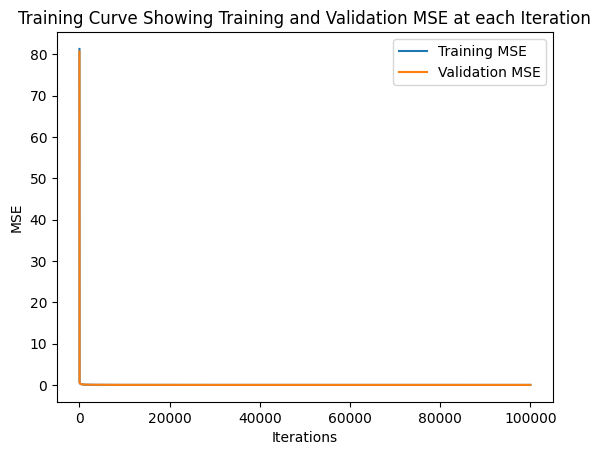

Final Training MSE: 0.009165247765844188
Final Validation MSE: 0.01644889927242079


In [742]:
w = gradient_descent(alpha=0.01, n_iter=100000, plot=True)

We can see that both the training and validation MSEs converge quite quickly, and we have obtained very low training and validation MSEs, thus we have our optimal weights.

In [743]:
np.save("weights.npy", w)

### **Making Predictions**

In [744]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

 # Replace NAN entries for numeric columns.
test_data[zero_fill_cols] = test_data[zero_fill_cols].fillna(0)
test_data[median_fill_cols] = test_data[median_fill_cols].fillna(data[median_fill_cols].median())

# For the other categorical columns, fill with "None".
test_data.fillna("None", inplace=True)

#test_data.drop("Street", axis=1, inplace=True)
#test_data.drop("Utilities", axis=1, inplace=True)

#test_data = test_data.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence", "GarageYrBlt"])

test_data = test_data.drop(columns=["Street", "Utilities", "PoolQC", "MiscFeature", "GarageYrBlt"])

test_data[log_cols] = np.log1p(test_data[log_cols])

for col in obj_cols:
    categories = list(test_data[col].unique())
    
    if "None" not in categories:
        categories.append("None")
            
    create_categorical_variables(test_data, col, categories)

for col2 in numeric_categorize_cols:
    categories = test_data[col2].unique().astype(str).tolist()

    if "None" not in categories:
        categories.append("None")
        
    create_categorical_variables(test_data, col2, categories)



 Creating Categorical Variables for column MSZoning:
 Created: MSZoning-RH
 Created: MSZoning-RL
 Created: MSZoning-RM
 Created: MSZoning-FV
 Created: MSZoning-C (all)
 Created: MSZoning-None

 Creating Categorical Variables for column Alley:
 Created: Alley-None
 Created: Alley-Pave
 Created: Alley-Grvl

 Creating Categorical Variables for column LotShape:
 Created: LotShape-Reg
 Created: LotShape-IR1
 Created: LotShape-IR2
 Created: LotShape-IR3
 Created: LotShape-None

 Creating Categorical Variables for column LandContour:
 Created: LandContour-Lvl
 Created: LandContour-HLS
 Created: LandContour-Bnk
 Created: LandContour-Low
 Created: LandContour-None

 Creating Categorical Variables for column LotConfig:
 Created: LotConfig-Inside
 Created: LotConfig-Corner
 Created: LotConfig-FR2
 Created: LotConfig-CulDSac
 Created: LotConfig-FR3
 Created: LotConfig-None

 Creating Categorical Variables for column LandSlope:
 Created: LandSlope-Gtl
 Created: LandSlope-Mod
 Created: LandSlope-Se

In [745]:
test_ids = test_data["Id"]

X_test = test_data.drop(columns=["Id"])

X_test[norm_cols] = (X_test[norm_cols] - mean) / std

#feature_order = pd.read_csv("feature_order.csv").iloc[:,0].tolist()

X_test = X_test.reindex(columns=feature_order, fill_value=0)

X_test = X_test.values

# Add bias column
b_test = np.ones((X_test.shape[0], 1))

X_test = np.concatenate([X_test, b_test], axis=1)

In [746]:
y = np.exp(np.dot(X_test, w))

pred_df = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": y
})

pred_df.to_csv("predictions.csv", index=False)